# 1.特征选择

In [73]:
import numpy as np
import pandas as pd

## 低方差过滤法

In [74]:
x_feature = np.random.normal(0,4,(2,5))
# print(x_feature)
y_feature = np.random.normal(0,1,(4,5))
# print(y_feature)
feature =  np.vstack((x_feature,y_feature)).T
print(feature)

[[-4.92543718  1.02724661  0.9178846   1.67238036  0.44898742  0.50547742]
 [ 3.59132964 -5.02307758 -1.3935561  -1.21965066  0.75942714 -0.66294577]
 [-3.60526188  0.97060488  0.01047208 -1.6802132  -0.69317543  1.31294737]
 [-5.99955732  7.85954047 -0.15794886  1.08182786  0.50827194  0.84989798]
 [ 1.53005524  2.99807541 -0.97390484  0.59345904  0.35736831 -0.24250743]]


In [75]:
feature_var =  np.var(feature,axis=1)
print(feature_var)
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold= 2)

x_filterd = vt.fit_transform(feature)

print(x_filterd)

[ 4.89846832  6.66272051  2.78413184 16.18060429  1.63141924]
[[-4.92543718  1.02724661]
 [ 3.59132964 -5.02307758]
 [-3.60526188  0.97060488]
 [-5.99955732  7.85954047]
 [ 1.53005524  2.99807541]]


## 皮尔逊相关系数

In [76]:
x1 = np.random.rand(10)*10
y = 2*x1 +4
xn = np.random.rand(3,10)
feature = np.vstack((x1,xn,y)).T
print(feature)

[[ 7.62580715  0.83132925  0.94422836  0.81703447 19.2516143 ]
 [ 0.565778    0.77247842  0.34780505  0.33112297  5.131556  ]
 [ 8.34741663  0.32299178  0.51188164  0.4925258  20.69483325]
 [ 6.49884468  0.65339487  0.49915764  0.61805731 16.99768937]
 [ 7.94172945  0.74814303  0.83630826  0.98444949 19.8834589 ]
 [ 5.21310785  0.65619666  0.24897191  0.89309809 14.42621569]
 [ 7.88616381  0.91529907  0.17507377  0.15985687 19.77232763]
 [ 5.73678615  0.59343982  0.21980787  0.8857645  15.4735723 ]
 [ 0.57239339  0.97361005  0.9151877   0.34273497  5.14478679]
 [ 4.58830183  0.7903369   0.42447889  0.8815154  13.17660367]]


In [77]:
df_feature = pd.DataFrame(feature)
print(df_feature)

          0         1         2         3          4
0  7.625807  0.831329  0.944228  0.817034  19.251614
1  0.565778  0.772478  0.347805  0.331123   5.131556
2  8.347417  0.322992  0.511882  0.492526  20.694833
3  6.498845  0.653395  0.499158  0.618057  16.997689
4  7.941729  0.748143  0.836308  0.984449  19.883459
5  5.213108  0.656197  0.248972  0.893098  14.426216
6  7.886164  0.915299  0.175074  0.159857  19.772328
7  5.736786  0.593440  0.219808  0.885764  15.473572
8  0.572393  0.973610  0.915188  0.342735   5.144787
9  4.588302  0.790337  0.424479  0.881515  13.176604


In [78]:
corr_matrix =  df_feature.corr(method= "pearson")
print(corr_matrix)

          0         1         2         3         4
0  1.000000 -0.420462 -0.026149  0.314126  1.000000
1 -0.420462  1.000000  0.277834 -0.260581 -0.420462
2 -0.026149  0.277834  1.000000  0.159352 -0.026149
3  0.314126 -0.260581  0.159352  1.000000  0.314126
4  1.000000 -0.420462 -0.026149  0.314126  1.000000


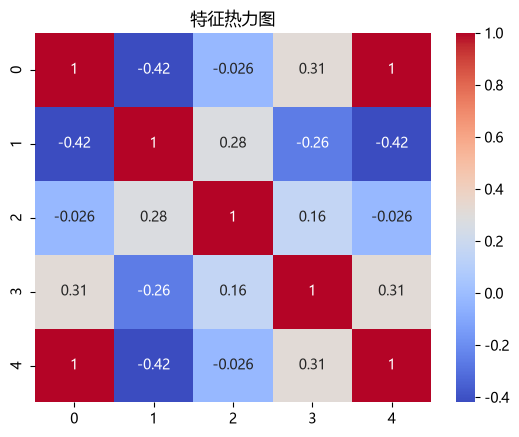

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

sns.heatmap(corr_matrix, annot= True,cmap='coolwarm')
plt.title('特征热力图')
plt.show()

## 斯皮尔曼相关系数

与上面代码相同 反映非线性相关性

# 2.特征转换法

## 标准化

In [80]:
from sklearn.preprocessing  import MinMaxScaler,StandardScaler,LabelEncoder,OneHotEncoder
import os
from pkg.pathset import parent_abs
print(parent_abs)

df_data = pd.read_csv(os.path.join(parent_abs,'data','penguins.csv'))
print(df_data.shape)

E:\self_code\ml_dl_nlp
(344, 7)


In [81]:
num_data = df_data.loc[:,['bill_depth_mm','bill_length_mm','flipper_length_mm']]
print(num_data.shape)
num_data = num_data.dropna()

(344, 3)


In [ ]:

scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(num_data)
print(data_std[0:5,:])

[[ 0.78544923 -0.88449874 -1.41834665]
 [ 0.1261879  -0.81112573 -1.06225022]
 [ 0.43046236 -0.66437972 -0.42127665]
 [ 1.08972369 -1.32473679 -0.56371522]
 [ 1.74898502 -0.84781224 -0.77737308]]


## 归一化

In [ ]:
scaler_uni = MinMaxScaler()
data_uni = scaler_uni.fit_transform(num_data)
print(data_uni[0:5,:])

[[0.66666667 0.25454545 0.15254237]
 [0.51190476 0.26909091 0.23728814]
 [0.58333333 0.29818182 0.38983051]
 [0.73809524 0.16727273 0.3559322 ]
 [0.89285714 0.26181818 0.30508475]]


In [84]:
cat_data = df_data.loc[:,['island','species']]
print(cat_data.head())

      island species
0  Torgersen  Adelie
1  Torgersen  Adelie
2  Torgersen  Adelie
3  Torgersen  Adelie
4  Torgersen  Adelie


## 独热编码

In [ ]:
scaler_oh = OneHotEncoder(sparse_output=False)
hot_data = scaler_oh.fit_transform(cat_data)
print(hot_data[0:5,:])

[[0. 0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0.]]


## 标签编码

In [ ]:
scaler_label = LabelEncoder()
cat_data = np.array(cat_data)
lable_data = scaler_label.fit_transform(cat_data.T[0])
print(lable_data)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0]


# 3.PCA特征降维

[[ 0.58554671 -1.10139314]
 [-3.34211917  0.18963171]
 [-0.56526603 -0.71965441]
 [ 2.55030868  2.33705929]
 [ 2.41279509 -1.16336305]]


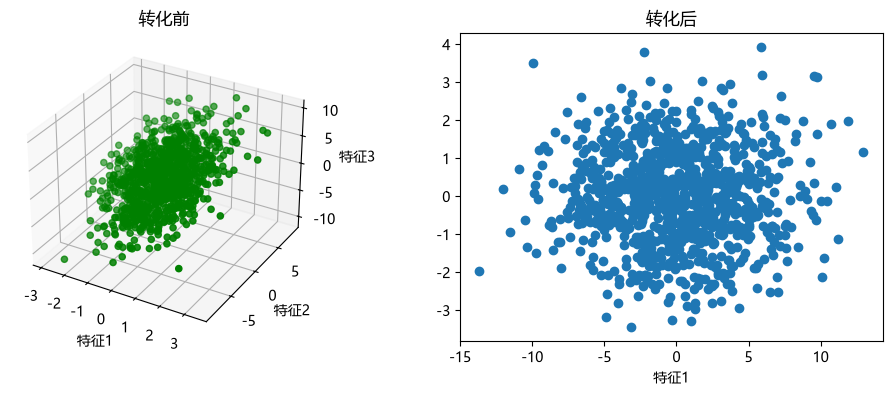

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
num_size = 1000

col1 = np.random.normal(0,1,size=num_size)
col2 = np.random.normal(0,0.2,size=num_size)
col3 = np.random.normal(0,3,size=num_size)

data_befor = np.vstack([col1+col2,col2+col3,col3+col1])


scaler_pca = PCA(n_components=2)

data_after = scaler_pca.fit_transform(data_befor.T)
print(data_after[0:5,:])

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(121,projection='3d')
ax1.scatter(data_befor[0],data_befor[1],data_befor[2],c='g')
ax1.set_title('转化前')
ax1.set_xlabel('特征1')
ax1.set_ylabel('特征2')
ax1.set_zlabel('特征3')

ax2 = fig.add_subplot(122)
ax2.scatter(data_after[:,0],data_after[:,1])
ax2.set_title('转化后')
ax2.set_xlabel('特征1')
ax2.set_label('特征2')

plt.show()